(100, 500, 2)
(100, 32, 20)


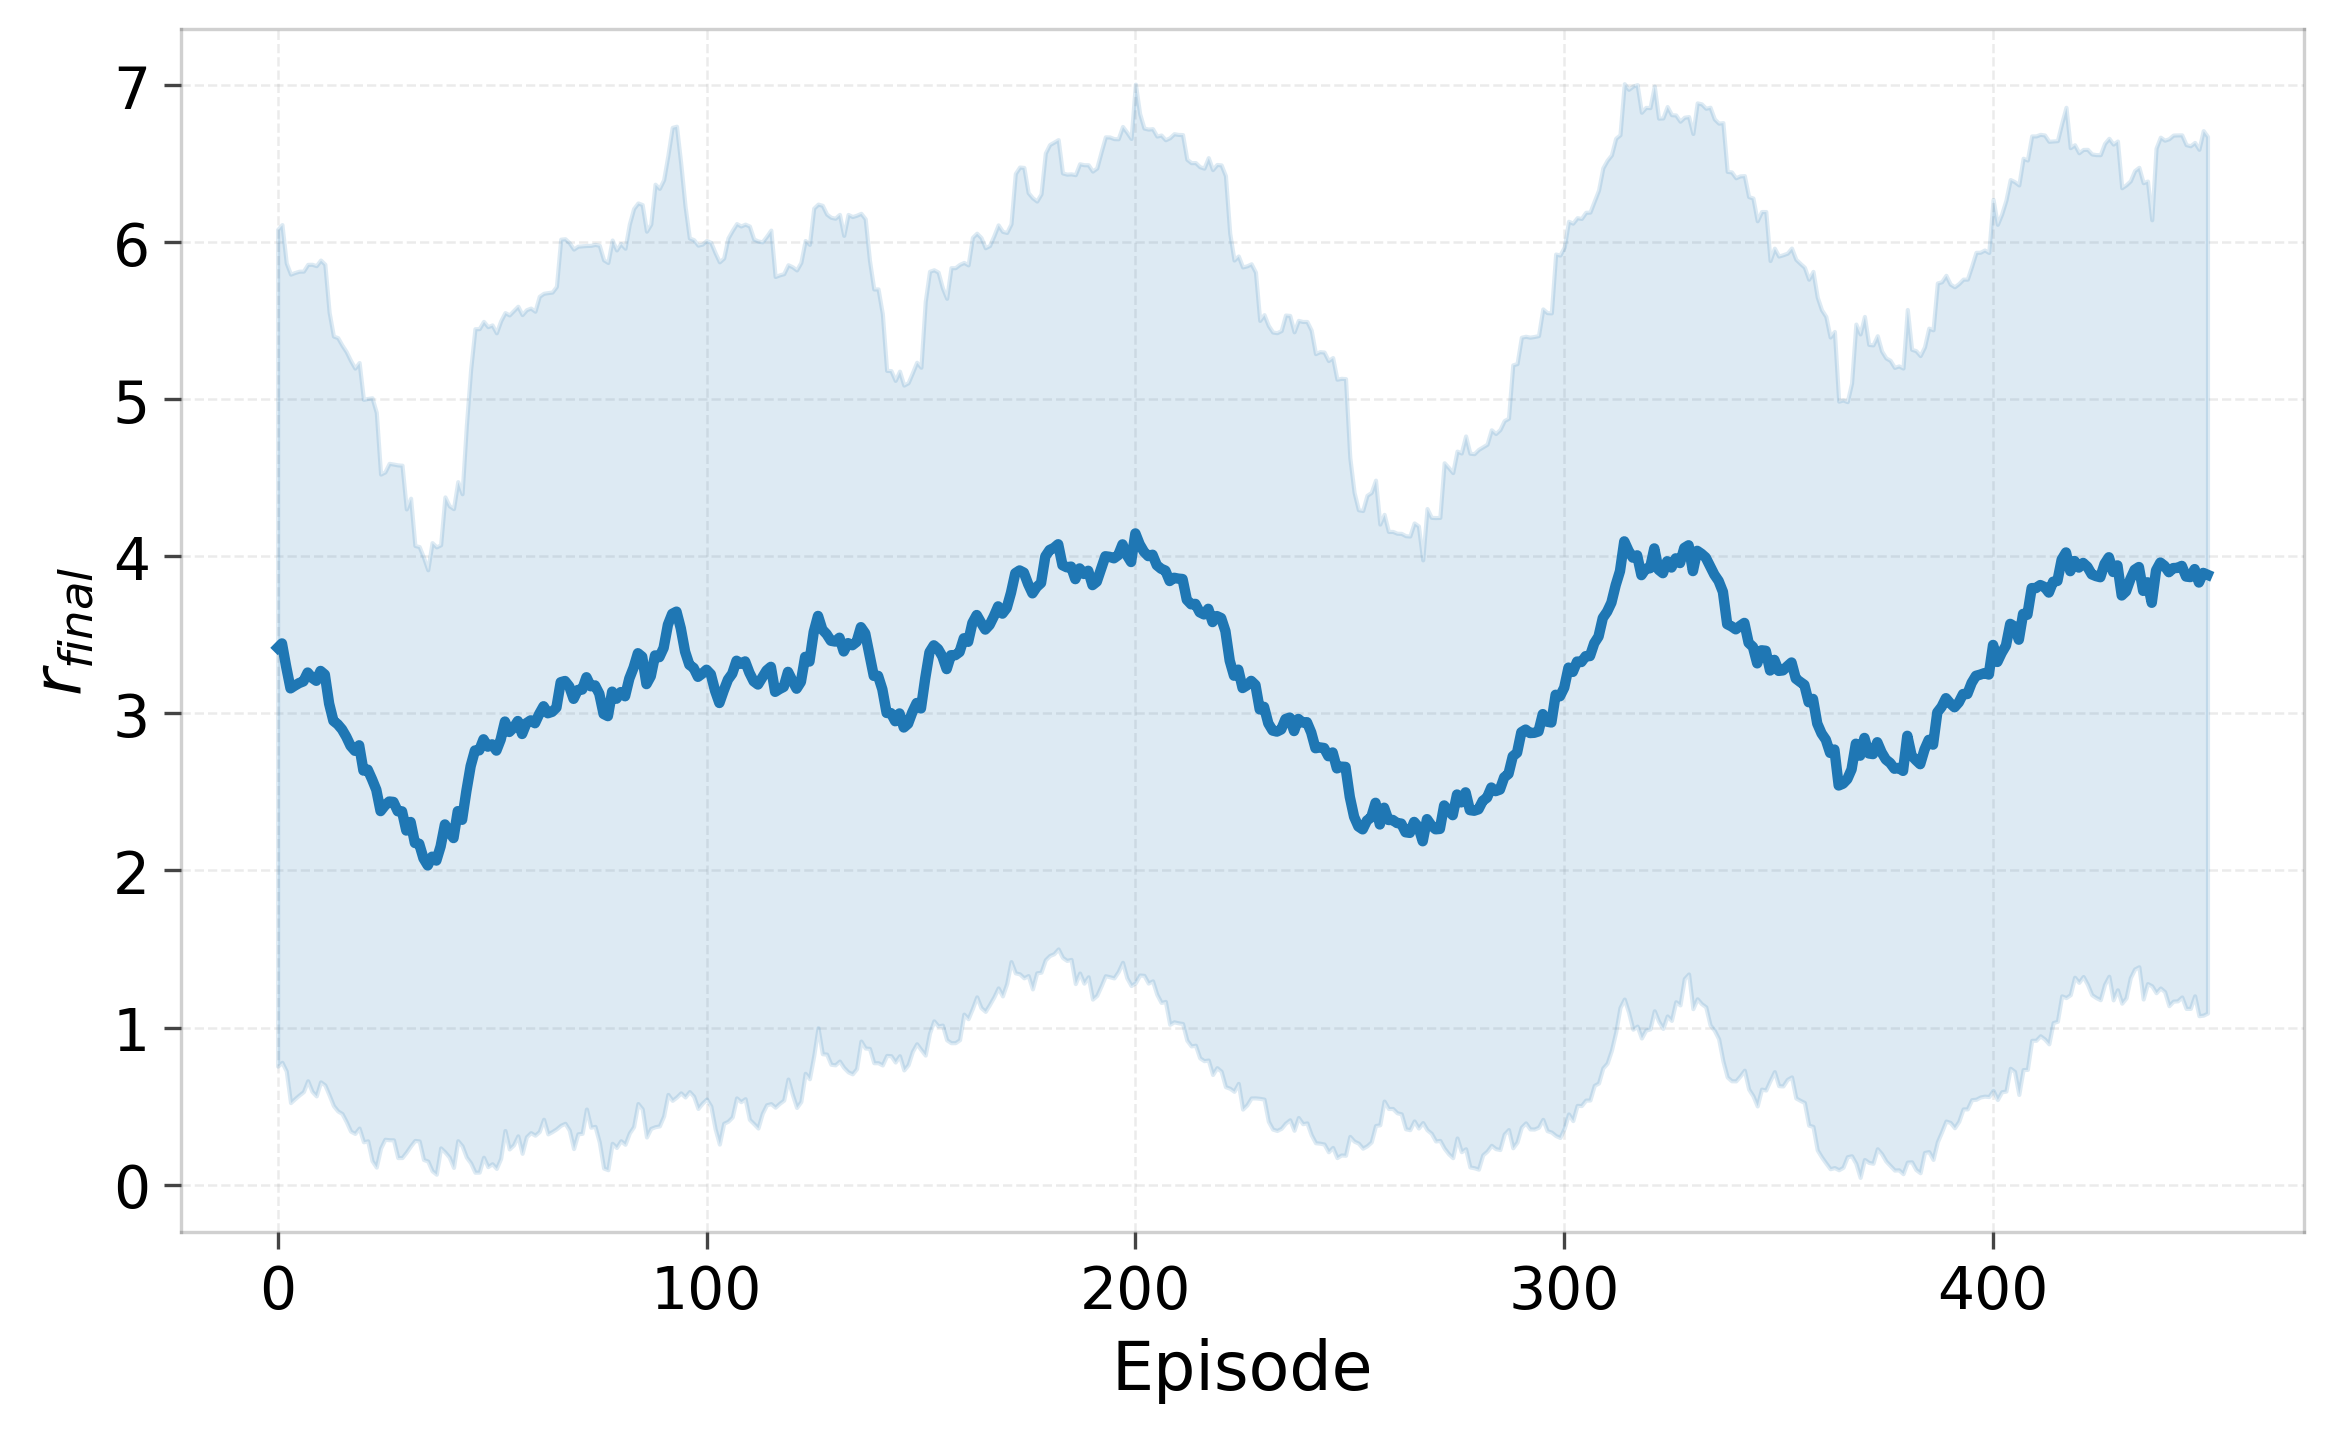

In [7]:
##Based on the originality without bias, classify the structures based on the bandgap
import numpy as np
import matplotlib.pyplot as plt
import random
import sys
sys.path.append("..")

from utils.utils import build_p4m_structure_simple, check_4_connectivity_single_component, get_fundamental_grid, strictly_enforce_4_connectivity

loadData = np.load("Updated_SAC_DISCRETE_3cm_steel_refined.npy",allow_pickle=True)
bandgaps= [val['bandgap'] for val in loadData]
rewards = [val['rewards'] for val in loadData]
rewards = np.sum(rewards, axis=1)
rewards_arr = np.array(rewards)/500

#print(rewards_arr)
#random.seed(1234)
idx= np.where(rewards_arr >4)[0]
idx = np.random.choice(idx, 100)
# print(idx)

states = [val['states'] for val in loadData]
states = [np.array(state) for state in states]
states = np.array(states)[idx]

bandgaps= [np.array(x) for x in bandgaps]
bandgaps = [bandgaps[i] for i in idx]
print(np.shape(states)) #path
print(np.shape(bandgaps))


#plot reward based on std and mean
#Global scheme

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2})
####################################
window = 50
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='valid')

def moving_std(x, w):
    return np.array([np.std(x[i:i+w]) for i in range(len(x)-w+1)])

ma = moving_average(rewards_arr, window)
std = moving_std(rewards_arr, window)

episodes = np.arange(len(ma))
#confidence Bounds
upper = ma + std
lower = ma - std

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.plot(episodes, ma, linewidth=2.5, color="#1f77b4")
ax.fill_between(episodes, lower, upper, alpha=0.15, color="#1f77b4")

ax.set_xlabel("Episode", fontsize=16)
ax.set_ylabel(r"$r_{final}$", fontsize=16)

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.25)
ax.set_axisbelow(True)
#more of annotation, can be removed)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("#444444")
    spine.set_alpha(0.25)

ax.tick_params(axis="both", which="major",
               labelsize=14,
               length=4,
               width=0.8,
               color="#444444")

ax.tick_params(top=False, right=False)

plt.tight_layout()
plt.savefig("Updated_SAC_DISCRETE_3cm_WO_history_reward_STEEL.png", dpi=500, bbox_inches='tight')
#plt.close()

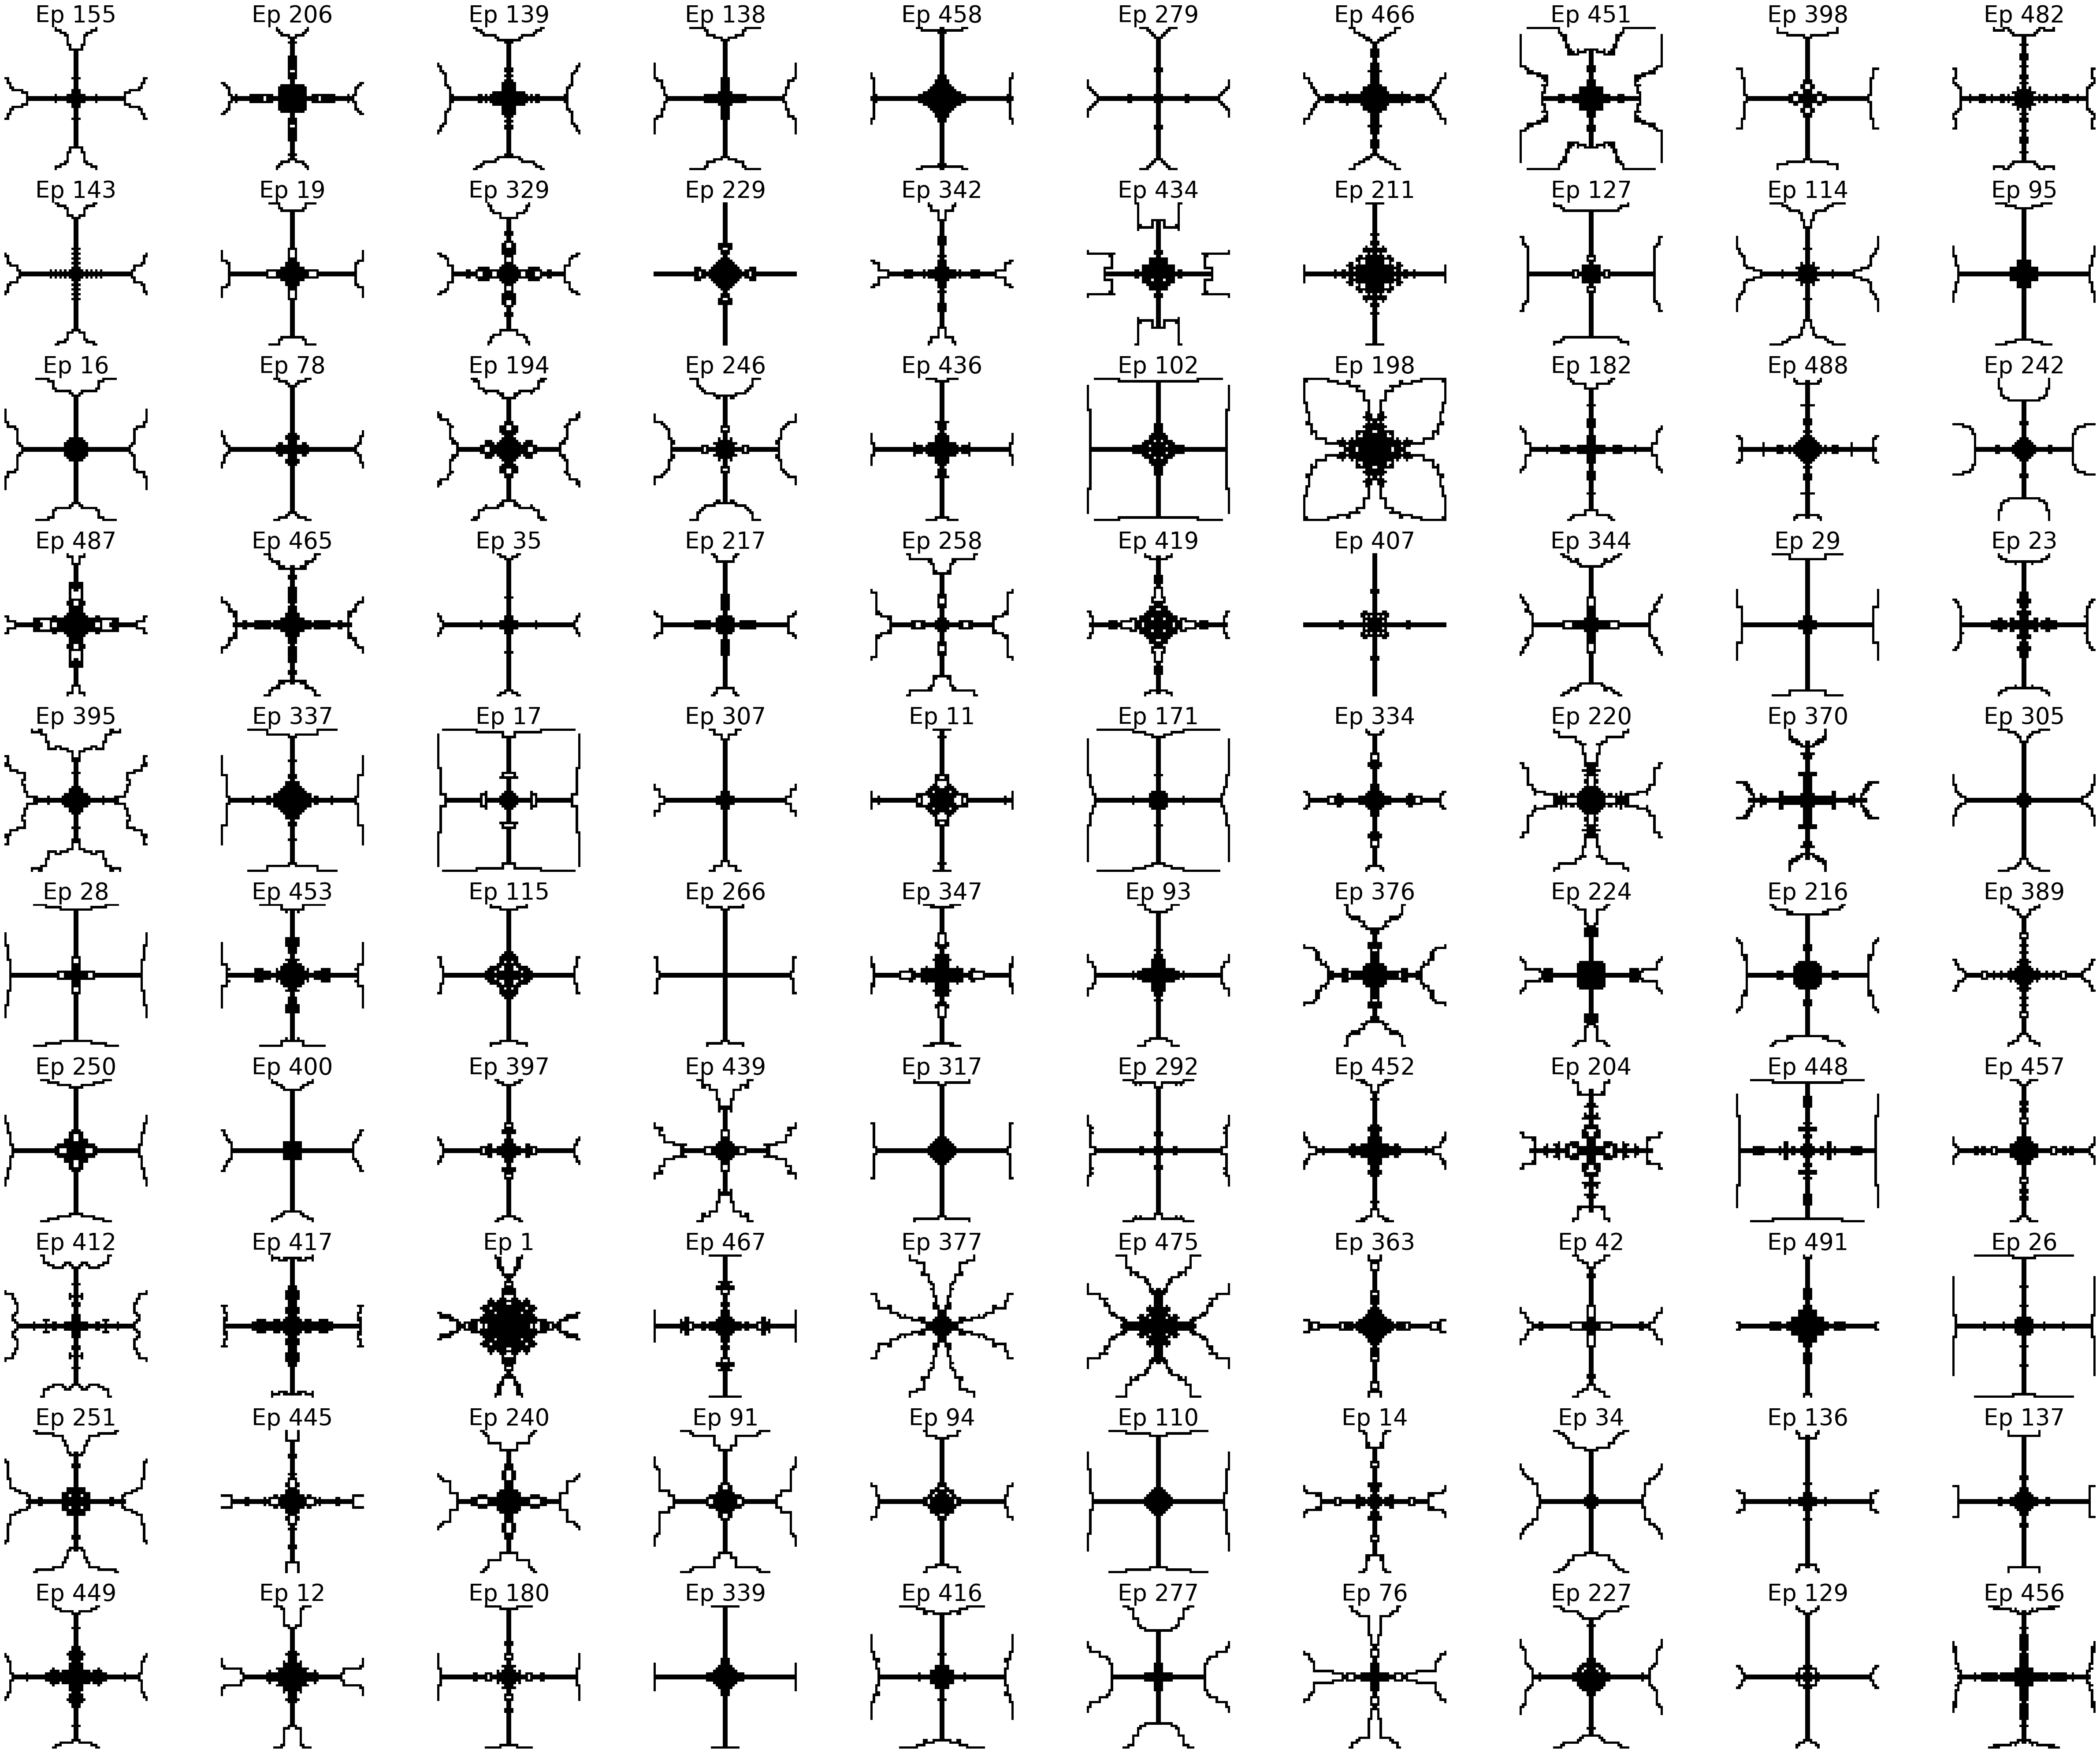

In [8]:
from scipy.ndimage import label, generate_binary_structure

Fullgrid = 60

rng = np.random.default_rng(3)

idx = np.where(rewards_arr > 4)[0]
rx = rng.choice(idx, 100, replace=False)

states = [val['states'] for val in loadData]
states = [np.array(state) for state in states]
states = np.array(states)[rx]

new_states = states#np.array(states)[pos_rew]

fig, axes = plt.subplots(10, 10, figsize=(50,40))
axes = axes.flatten()

for i in range(100):
    path1 = np.asarray(new_states[i], dtype=int)
    path1 = np.unique(path1, axis=0)

    fundgrid = get_fundamental_grid(30, path1)
    Fullgrid = build_p4m_structure_simple(fundgrid)
    Fullgrid = strictly_enforce_4_connectivity(Fullgrid)
    is_conn, n_grids = check_4_connectivity_single_component(Fullgrid)
    if is_conn:    
        axes[i].imshow(Fullgrid, cmap="gray", origin="lower")
        axes[i].set_title(f"Ep {rx[i]}", fontsize=38)
        axes[i].axis("off")

plt.tight_layout()
plt.show()


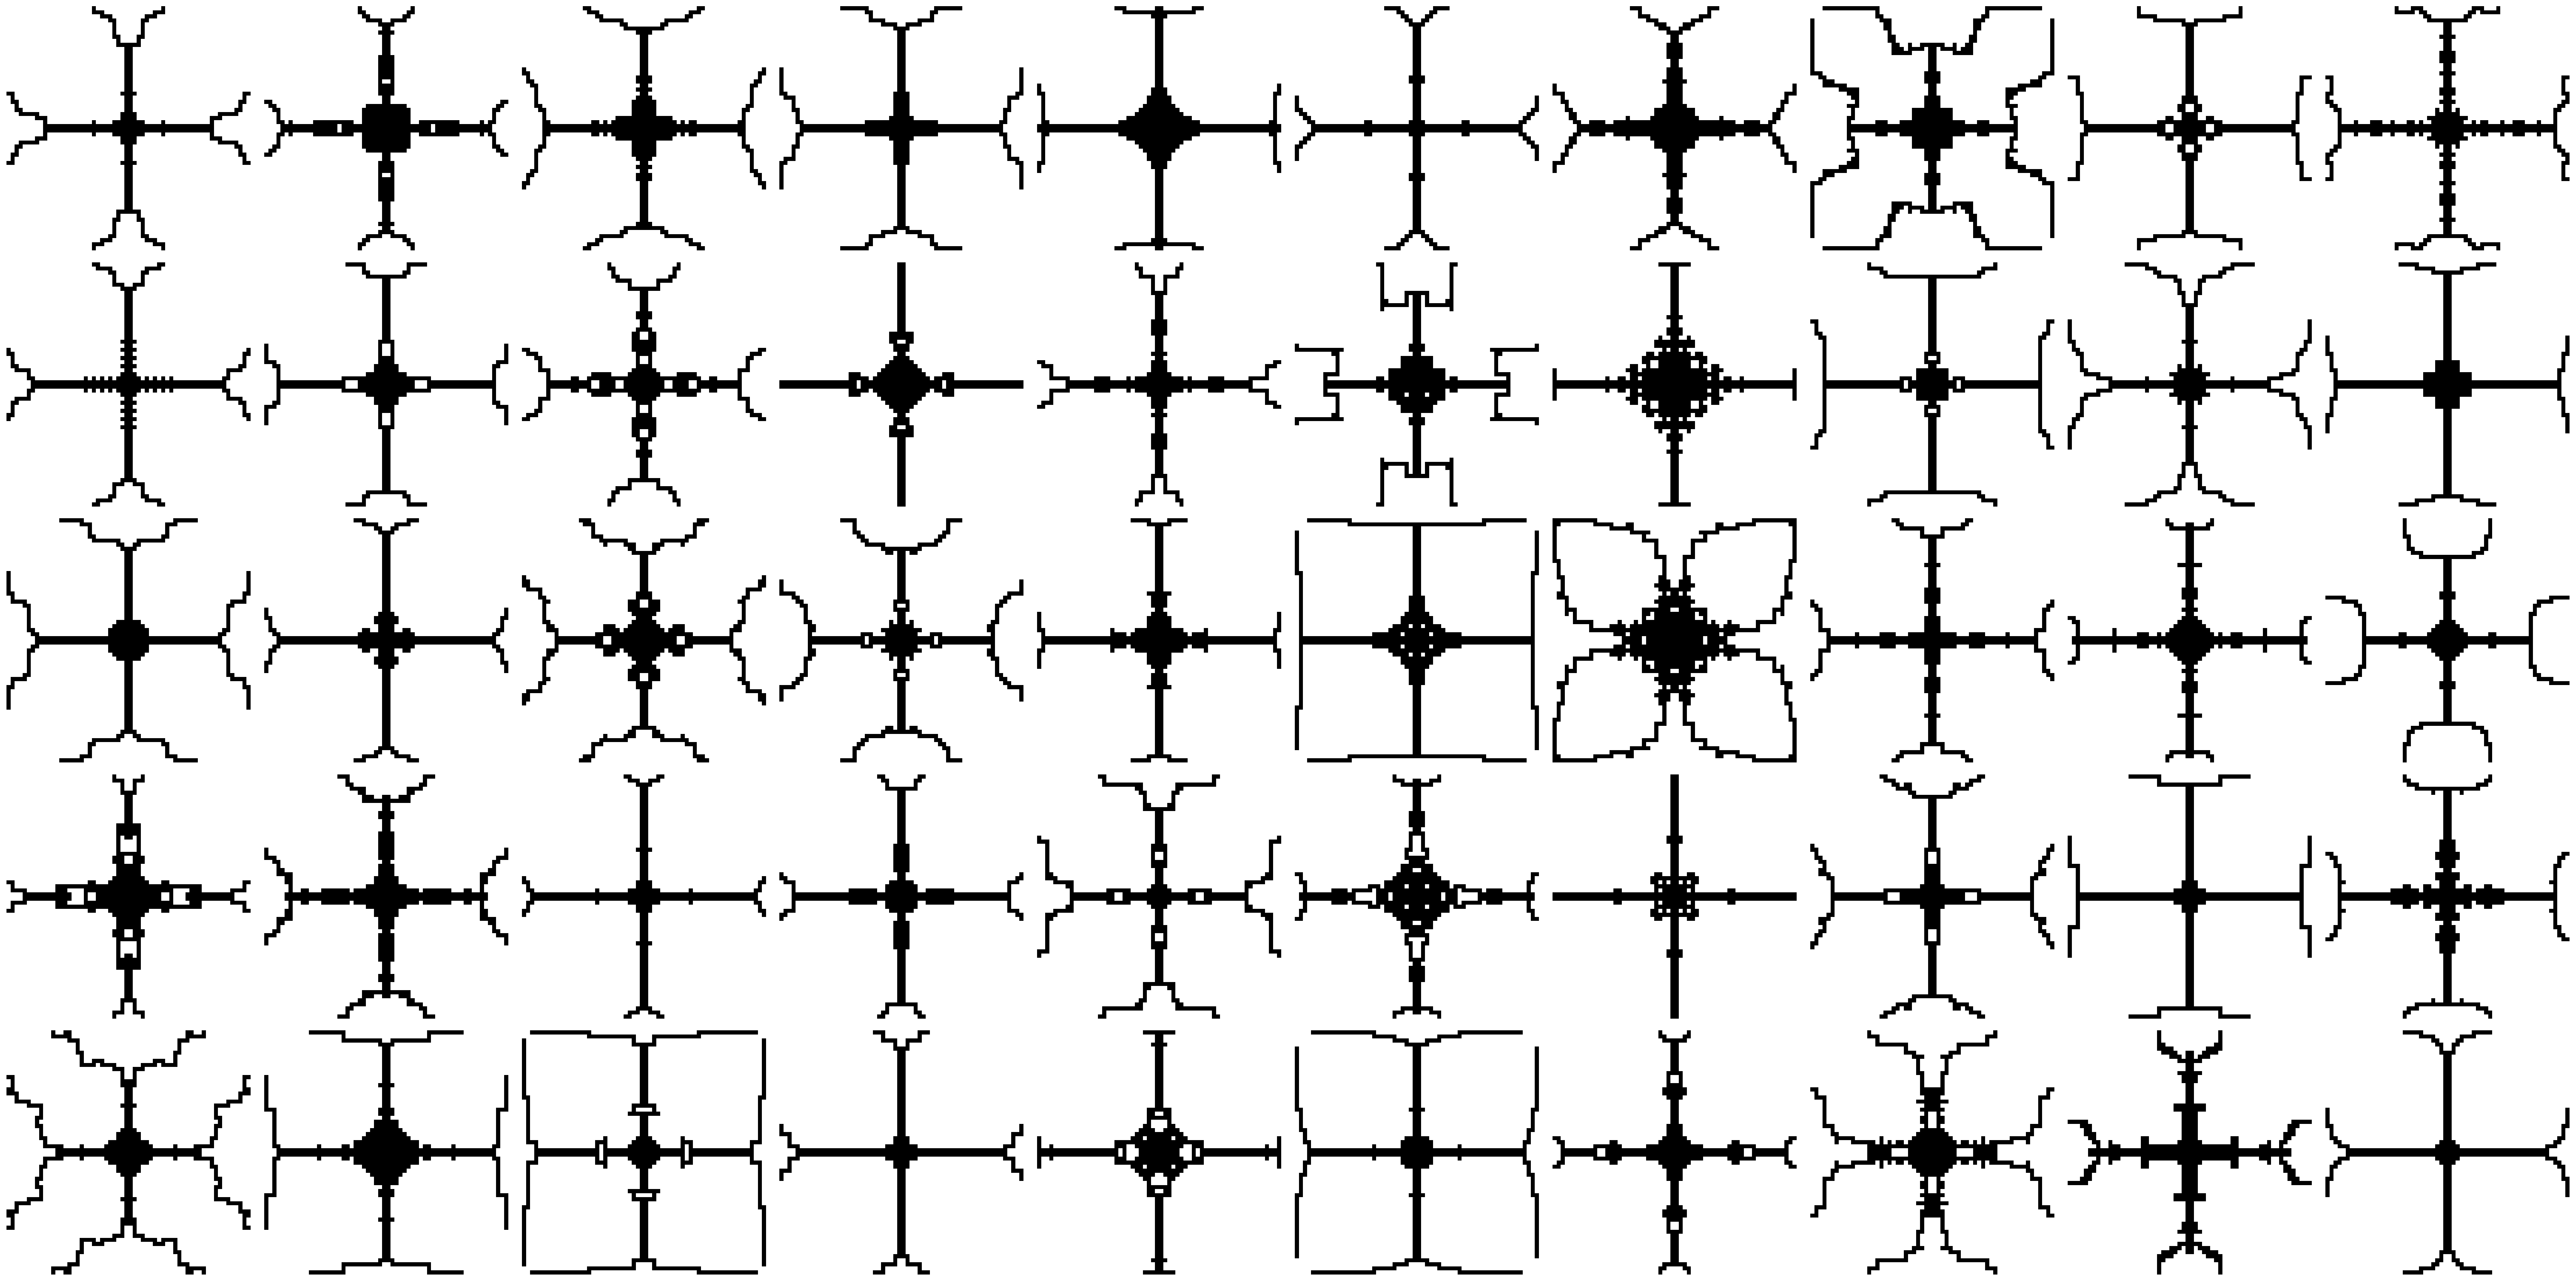

In [9]:
fig, axes = plt.subplots(5, 10, figsize=(40, 20),dpi=200)
axes = axes.flatten()

for i in range(50):
    r, c = divmod(i, 50)

    path1 = np.asarray(new_states[i], dtype=int)
    path1 = np.unique(path1, axis=0)

    fundgrid = get_fundamental_grid(30, path1)
    Fullgrid = build_p4m_structure_simple(fundgrid)
    Fullgrid = strictly_enforce_4_connectivity(Fullgrid)
    is_conn, n_grids = check_4_connectivity_single_component(Fullgrid)

    if is_conn:
        ax = axes[i]
        ax.imshow(Fullgrid, cmap="gray", origin="lower")
        ax.axis("off")


plt.tight_layout()
plt.savefig("Updated_SAC_DISCRETE_3cm_STEEL_STATES.png", dpi=500, bbox_inches='tight')
plt.show()
#plt.close()


(32, 20)


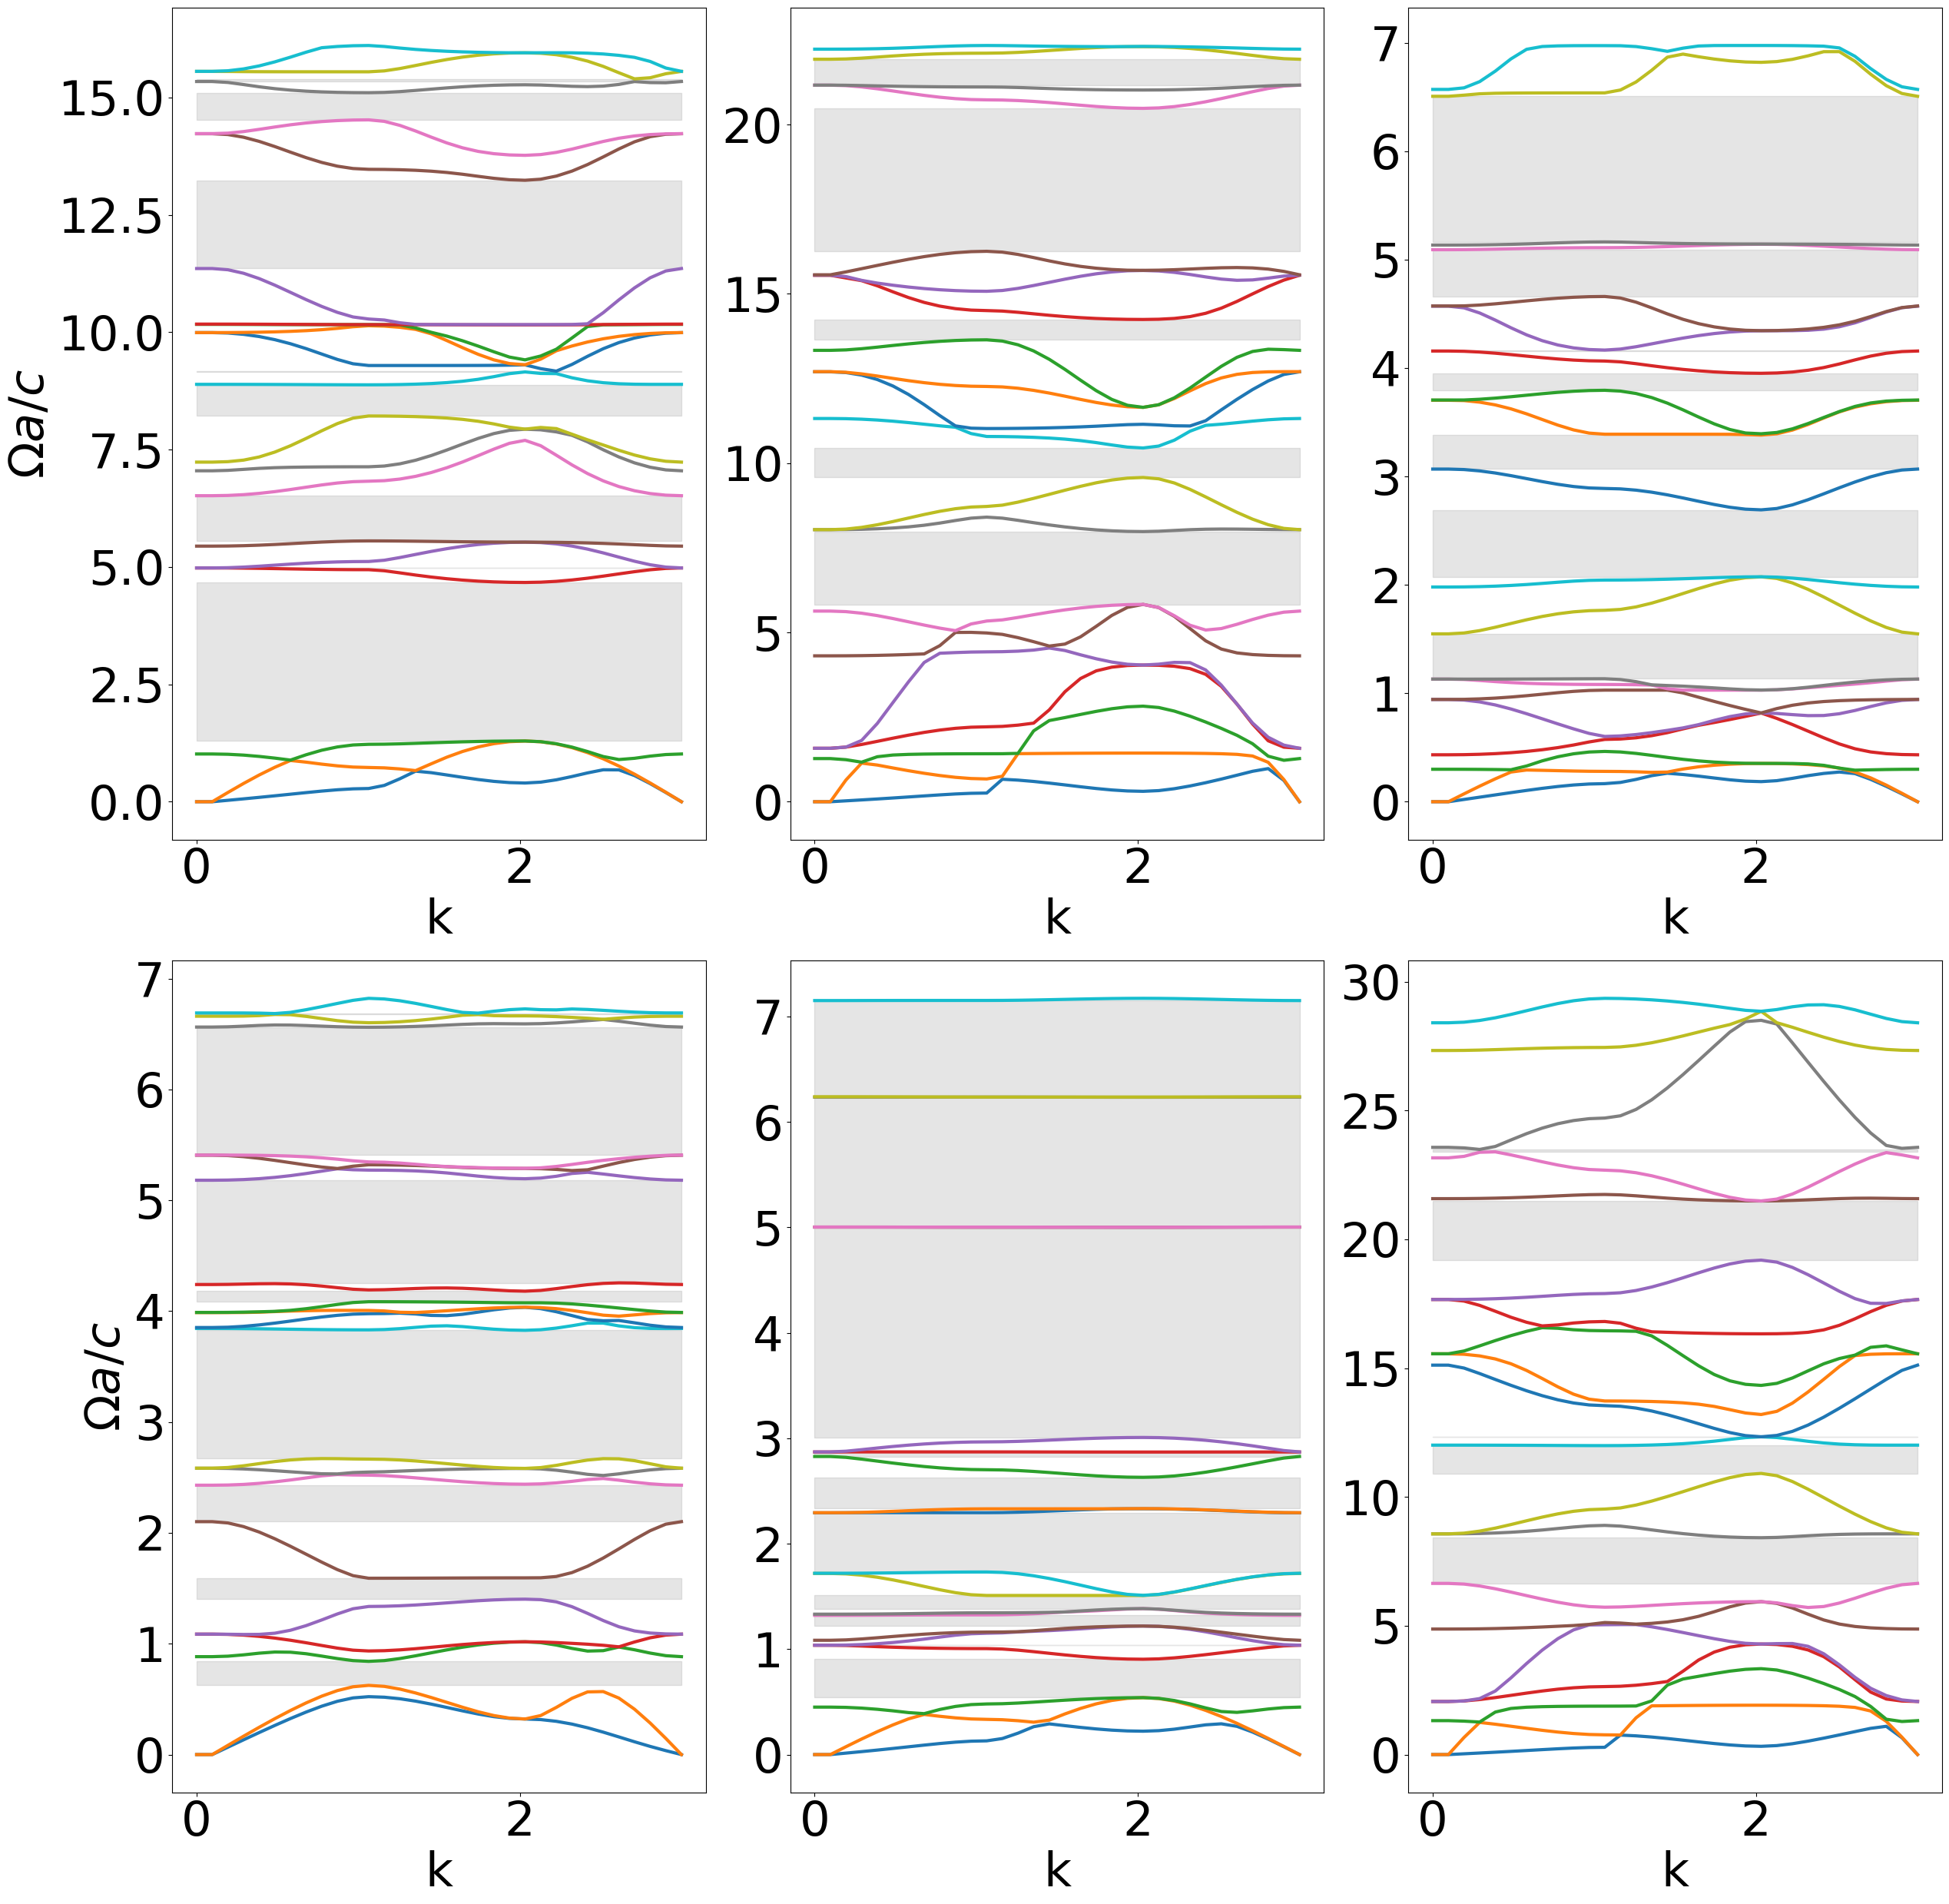

In [10]:
#Based on the index get the bandgap
import numpy as np
import matplotlib.pyplot as plt

bandgaps= [val['bandgap'] for val in loadData]
bandgaps= [np.array(bng) for bng in bandgaps]
bandgapsx = [bandgaps[i] for i in rx]
print(np.shape(np.array(bandgaps[0])))
k= np.linspace(0,3,32)

band_high3 = bandgapsx #np.array(bandgaps)[rm]#bandgapsx#

############Instead plot only selected 10 bandgaps###############
selected_idx = [1,11,97,198, 434, 483]
fig, axes = plt.subplots(2, 3, figsize=(25, 25))
axes = axes.flatten()

for i in range(6):
    data = bandgaps[selected_idx[i]] * 0.04 / 343  # shape (32, 20)
    data_sorted = np.sort(data, axis=1)
    # Plot bands
    axes[i].plot(k, data_sorted, linewidth=3)
    # Loop over adjacent band pairs
    for b in range(data_sorted.shape[1] - 1):
        lower = data_sorted[:, b]
        upper = data_sorted[:, b + 1]

        lower_max = np.max(lower)
        upper_min = np.min(upper)
        
        # Check for global bandgap
        if upper_min > lower_max:
            axes[i].fill_between(
                k,
                lower_max,
                upper_min,
                color='gray',
                alpha=0.2
            )

    axes[i].set_xlabel("k", fontsize=45)

    if i % 3 == 0:
        axes[i].set_ylabel("$\\Omega a/c$", fontsize=45)
    else:
        axes[i].set_ylabel("")

    axes[i].tick_params(axis='both', labelsize=45)

plt.tight_layout()
plt.savefig("Updated_BANDGAP_wo_bias_3cm_Steel.png", dpi=500, bbox_inches='tight')

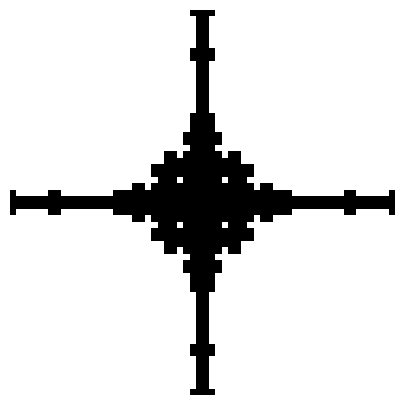

In [11]:
states = [val['states'] for val in loadData]
states = [np.array(state) for state in states]

plt.figure(figsize=(5,5))
for i in range(6):
    path1 = np.asarray(states[selected_idx[i]], dtype=int)
    path1 = np.unique(path1, axis=0)
    
    fundgrid = get_fundamental_grid(30, path1)
    Fullgrid = build_p4m_structure_simple(fundgrid)
    Fullgrid = strictly_enforce_4_connectivity(Fullgrid)
    is_conn, n_grids = check_4_connectivity_single_component(Fullgrid)
    
    plt.imshow(Fullgrid, cmap='gray')
    plt.xticks([])
    plt.yticks([])
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    plt.savefig(f"updated_unit_cell_{selected_idx[i]}.png", dpi=400, bbox_inches='tight')
